In [2]:
import pandas as pd
import json
import re
import numpy as np

In [4]:
inferencearr = []
graphllm = []
with open("output/scene_graphs/model_name_inference_llm_llm_model_name_7b_chat_llm_frozen_True_max_txt_len_512_max_new_tokens_32_gnn_model_name_gt_patience_2_num_epochs_10_seed0.csv") as f:
    while(x := f.readline()):
        inferencearr.append(json.loads(x))

with open("output/scene_graphs/model_name_graph_llm_llm_model_name_7b_llm_frozen_True_max_txt_len_512_max_new_tokens_32_gnn_model_name_gt_patience_2_num_epochs_10_seed0.csv") as f2:
    while(x := f2.readline()):
        graphllm.append(json.loads(x))

In [5]:
print(inferencearr[0].keys())
print(inferencearr[0])

#dict_keys(['id', 'pred', 'label', 'question', 'desc'])

dict_keys(['id', 'pred', 'label', 'question', 'desc'])
{'id': 7, 'pred': ' Based on the information provided in the diagram, we can determine that the following items are inside the box:\n\n1. Pizza\n2. Pe', 'label': 'pizza', 'question': 'Question: What is in the box?\n\nAnswer:', 'desc': 'node_id,node_attr\n1,"name: pizza; (x,y,w,h): (222, 254, 185, 138)"\n3,"name: pizza; attribute: sliced; (x,y,w,h): (190, 329, 231, 155)"\n4,"name: box; (x,y,w,h): (17, 214, 458, 268)"\n5,"name: pizza; (x,y,w,h): (17, 251, 137, 93)"\n7,"name: pepperoni; (x,y,w,h): (363, 288, 47, 24)"\n8,"name: woman; (x,y,w,h): (149, 16, 296, 282)"\n13,"name: pepperoni; (x,y,w,h): (276, 258, 29, 18)"\n\nsrc,edge_attr,dst\n1,to the right of,5\n1,topped with,7\n5,to the left of,13\n3,lying inside,4\n5,lying inside,4\n8,holding,4\n'}


### Accuracy Comparison between Inference LLM and Graph LLM

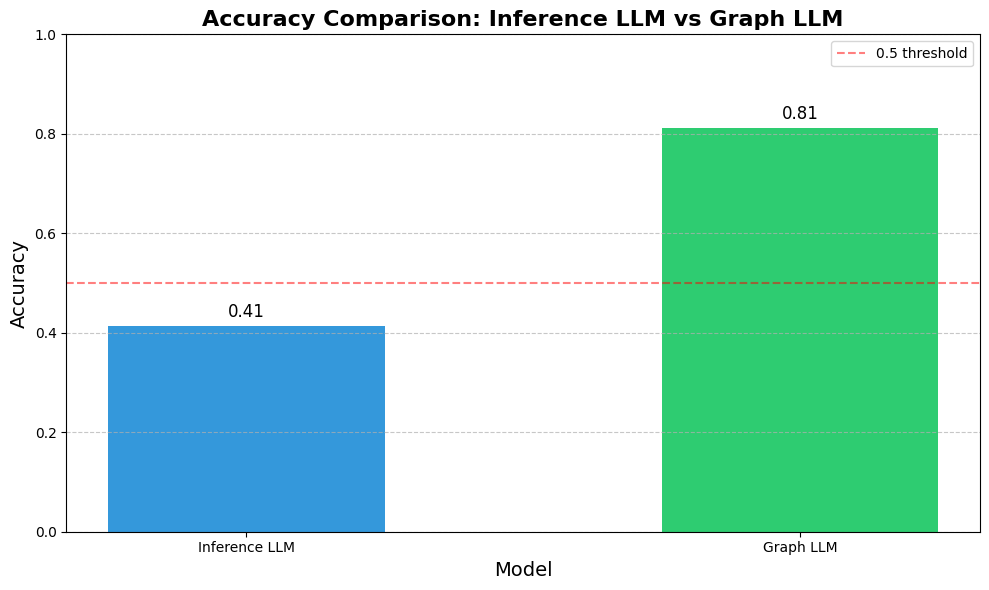

Graph LLM shows a 96.58% improvement over Inference LLM


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy values
models = ['Inference LLM', 'Graph LLM']
accuracies = [0.41333333333333333, 0.8125343320848939]

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], width=0.5)

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=12)

# Add labels and title
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.title('Accuracy Comparison: Inference LLM vs Graph LLM', fontsize=16, fontweight='bold')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis limits with some padding
plt.ylim(0, 1.0)

# Add a horizontal line at y=0.5 for reference
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')

plt.legend()
plt.tight_layout()
plt.show()

# Display improvement percentage
improvement = ((accuracies[1] - accuracies[0]) / accuracies[0]) * 100
print(f"Graph LLM shows a {improvement:.2f}% improvement over Inference LLM")



In [17]:
with open("./logs/train-22768.out", mode='r') as f:
    filearr = f.readlines()
    farr = filearr
    filearr = [x for x in filearr if x.find("Loss") != -1]
    accum = [x for x in filearr if x.find("Accum") != -1]
    epoch = [x for x in farr if x.find("Epoch") != -1 and x.find("|") != -1]
    lr = [x for x in farr if x.find("Lr") != -1]
    test = [x for x in farr if x.find("Test") != -1]


    temp = []
    for x in accum:
        temp.append(float(re.findall(r"\d+\.\d+|\d+", x)[0]))
    #accum =  [item for sublist in temp for item in sublist]
    accum = temp

    # filter epoch
    switch = False
    nums = []
    for x in epoch:
        nums.append(int(x[x.find("|")-1:x.find("|")]))

    temp = []
    for i,y in enumerate(epoch):
        temp.append([nums[i], "Val" if i%2==1 else "Train", float(re.findall(r"\d+\.\d+|\d+", y)[-1])])
    epoch = temp
    
    #filter lr
    temp = []
    for x in lr:
        for i,y in enumerate(x):
            if y.isdigit():
                temp.append(np.float64(x[i:]))
                break
    lr = temp

    #filter test
    test = float(re.findall(r"\d+\.\d+|\d+", test[0])[0])

    print(accum)
    #'4.623273134231567', '4.480338096618652
    print(epoch)
    # [0, 'Train', '0.543633476981705'], [0, 'Val', '0.3647212595697027'], (subsequently train and then val and so on)
    print(lr)
    # NUMPY FOMRAT [1.3338668800853675e-09, 4.001600640256103e-09, 6.6693344004268375e-09,
    print(test)
    #this value is constant
    #'Test Acc 0.8125343320848939\n']


[4.623273134231567, 4.480338096618652, 4.715644836425781, 4.77180290222168, 4.371520519256592, 4.56973934173584, 4.824961423873901, 4.6264073848724365, 4.5204079151153564, 4.877699851989746, 4.9582600593566895, 4.683200359344482, 4.772554874420166, 4.560182213783264, 4.842529296875, 4.95270562171936, 4.5650153160095215, 4.345846772193909, 3.8739458322525024, 3.9441230297088623, 4.775327920913696, 4.9766199588775635, 4.163806080818176, 4.520049333572388, 4.792805194854736, 4.118219375610352, 4.481970548629761, 3.775604009628296, 4.641017913818359, 3.924382448196411, 4.17754864692688, 4.535664796829224, 4.954266786575317, 4.589803457260132, 3.880944848060608, 4.591756582260132, 4.657206773757935, 4.788870573043823, 4.235496997833252, 4.426117897033691, 4.333075642585754, 4.7059760093688965, 4.182043790817261, 4.62744140625, 4.6825785636901855, 4.485304117202759, 4.5712971687316895, 4.76418662071228, 4.095495939254761, 4.518995642662048, 4.2765069007873535, 4.236379384994507, 4.2516412734

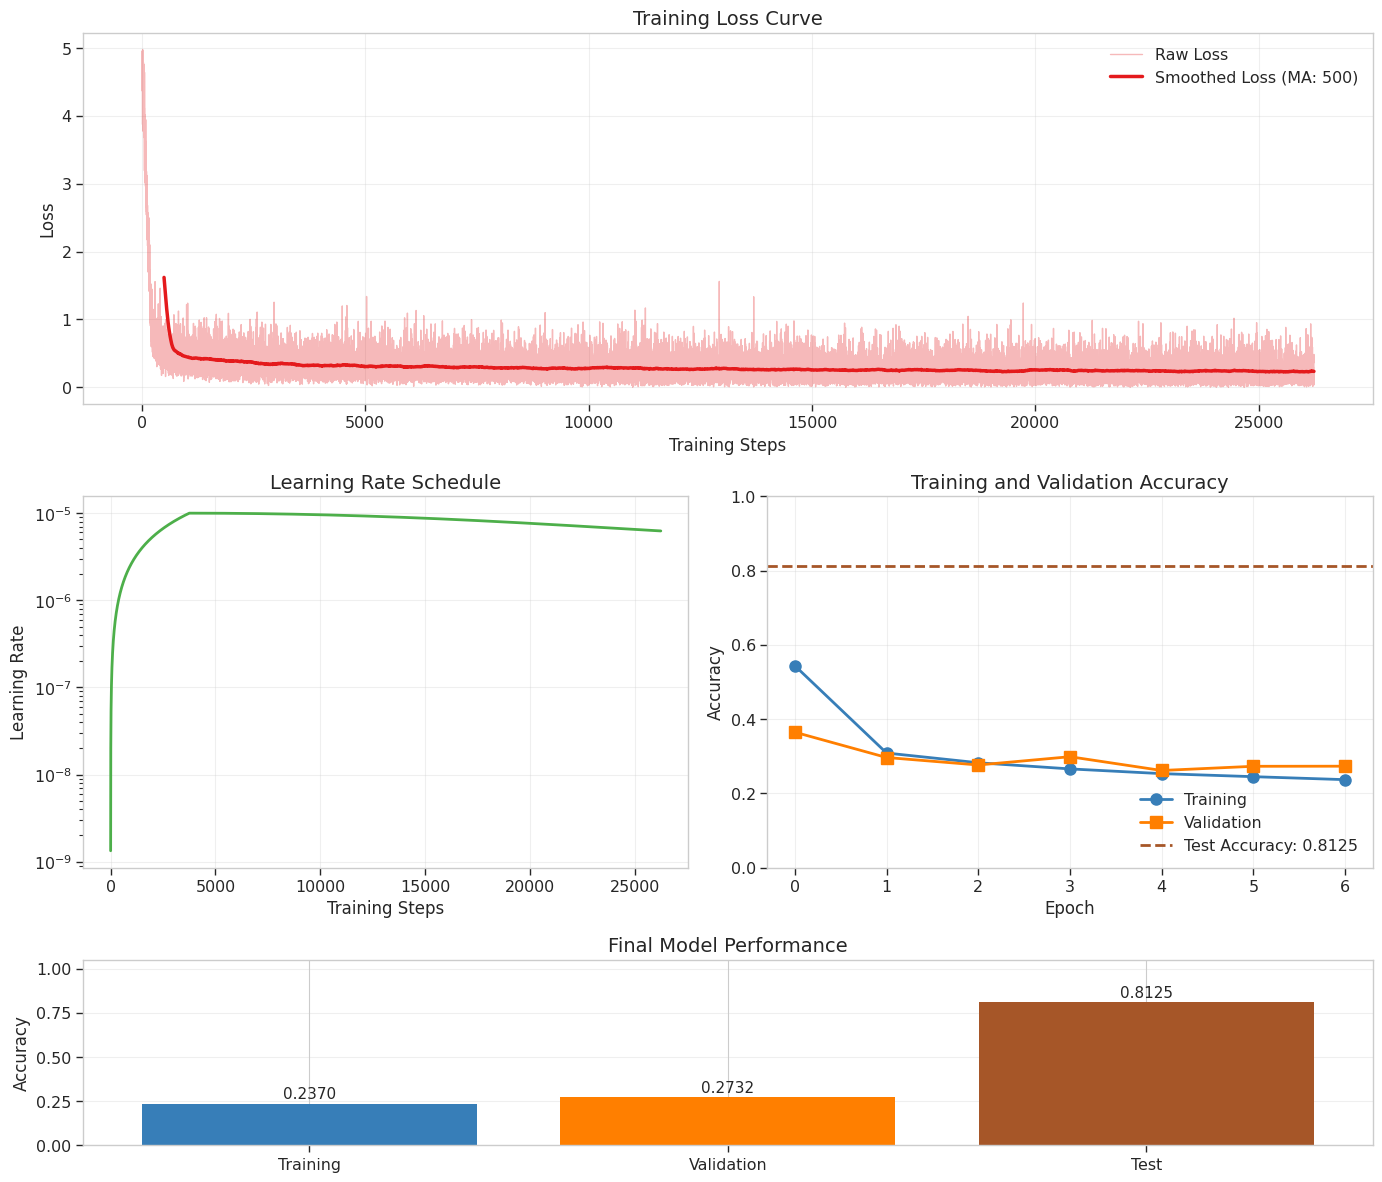

Final training accuracy: 0.2370
Final validation accuracy: 0.2732
Test accuracy: 0.8125
Initial loss: 4.6233
Final loss: 0.3626
Loss reduction: 92.16%


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Create figure with GridSpec for flexible layout
fig = plt.figure(figsize=(14, 12))
gs = GridSpec(3, 2, figure=fig, height_ratios=[2, 2, 1])

# 1. Plot training loss (with smoothing)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(range(len(accum)), accum, color='#E41A1C', alpha=0.3, linewidth=1, label='Raw Loss')

# Add smoothed trend line for better visibility
window_size = min(500, len(accum) // 20)  # Adjust window size based on data length
if window_size > 0:
    smoothed_loss = np.convolve(accum, np.ones(window_size)/window_size, mode='valid')
    ax1.plot(range(window_size-1, len(accum)), smoothed_loss, color='#E41A1C', 
             linewidth=2.5, label=f'Smoothed Loss (MA: {window_size})')

ax1.set_title('Training Loss Curve')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Plot learning rate
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(range(len(lr)), lr, color='#4DAF4A', linewidth=2)
ax2.set_title('Learning Rate Schedule')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Learning Rate')
ax2.set_yscale('log')  # Learning rates often viewed on log scale
ax2.grid(True, alpha=0.3)

# 3. Extract train/val accuracy by epoch
train_epochs = []
train_acc = []
val_epochs = []
val_acc = []

for item in epoch:
    if item[1] == 'Train':
        train_epochs.append(item[0])
        train_acc.append(item[2])
    else:  # 'Val'
        val_epochs.append(item[0])
        val_acc.append(item[2])

# 4. Plot train/val accuracy by epoch
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(train_epochs, train_acc, 'o-', color='#377EB8', linewidth=2, markersize=8, label='Training')
ax3.plot(val_epochs, val_acc, 's-', color='#FF7F00', linewidth=2, markersize=8, label='Validation')
ax3.axhline(y=test, color='#A65628', linestyle='--', linewidth=2, 
            label=f'Test Accuracy: {test:.4f}')
ax3.set_title('Training and Validation Accuracy')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right')

# 5. Final model performance comparison
ax4 = fig.add_subplot(gs[2, :])
model_types = ['Training', 'Validation', 'Test']
final_metrics = [train_acc[-1], val_acc[-1], test]
bars = ax4.bar(model_types, final_metrics, color=['#377EB8', '#FF7F00', '#A65628'])

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11)

ax4.set_title('Final Model Performance')
ax4.set_ylabel('Accuracy')
ax4.set_ylim([0, 1.05])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key metrics summary
print(f"Final training accuracy: {train_acc[-1]:.4f}")
print(f"Final validation accuracy: {val_acc[-1]:.4f}")
print(f"Test accuracy: {test:.4f}")
print(f"Initial loss: {accum[0]:.4f}")
print(f"Final loss: {accum[-1]:.4f}")
print(f"Loss reduction: {((accum[0] - accum[-1])/accum[0]*100):.2f}%")